# 09 · A live nowcast of Brazilian GDP

This notebook runs the complete production chain on the **latest** data:

1. download the indicators from their primary sources — the Central Bank's SGS
   (`fetch_sgs`), IBGE's SIDRA (`fetch_sidra`) and IPEADATA (`fetch_ipeadata`) — with
   a local disk cache;
2. transform and clean the panel;
3. estimate a mixed-frequency DFM with blocks and robust (Student-t) errors;
4. produce the nowcast of the current quarter with a predictive density;
5. explain the change since last month (news) and write an HTML report.

> **Network cells.** Downloading requires internet access and is **opt-in**: set the
> environment variable `NOWCASTBOX_EXAMPLES_NETWORK=1` before starting Jupyter. Without
> it — and whenever a download fails — the notebook falls back to the data shipped with
> the package (`load_brazil_nowcast`, built on 1 October 2026), so it always runs
> offline and in CI. The saved outputs below come from an **offline** run.

In [1]:
import sys
from pathlib import Path

HERE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
sys.path.insert(0, str(HERE.parent))

import pandas as pd
from utils import (
    BRAZIL_CORE,
    OUTPUTS_DIR,
    display,
    fetch_live_panel,
    md,
    network_enabled,
    pct,
    setup,
    show,
)

import nowcastbox as nb

setup()

## 1. Data: live download (network) or shipped fallback

In [2]:
dataset = nb.load_brazil_nowcast().select(list(BRAZIL_CORE))
LIVE = network_enabled()

if LIVE:  # --- network cell: runs only with NOWCASTBOX_EXAMPLES_NETWORK=1 ---------------
    levels, status = fetch_live_panel(dataset, start="2003-01-01")
    today = pd.Timestamp.today().normalize()
else:  # --- offline fallback: the data shipped with nowcastbox ------------------------
    levels = dataset.data
    status = pd.DataFrame(
        {"source": dataset.legend["source"], "origin": "shipped", "fallback reason": ""}
    )
    status["last observation"] = levels.last_observed()
    today = pd.Timestamp("2026-10-01")  # build date of the shipped dataset

md(
    f"Mode: **{'live (network)' if LIVE else 'offline (shipped data)'}**; reference date "
    f"**{today.date()}**; {int((status['origin'] == 'live').sum())} of {len(status)} "
    "series downloaded."
)
display(status)

Mode: **offline (shipped data)**; reference date **2026-10-01**; 0 of 22 series downloaded.

,source,origin,fallback reason,last observation
series,,,,
pib,IBGE/SIDRA,shipped,,2026-06
ibc_br,BCB/SGS,shipped,,2026-07
pim_geral,IBGE/SIDRA,shipped,,2026-07
pim_transformacao,IBGE/SIDRA,shipped,,2026-07
pim_bens_capital,IBGE/SIDRA,shipped,,2026-07
pim_bens_consumo_duraveis,IBGE/SIDRA,shipped,,2026-07
pmc_varejo,IBGE/SIDRA,shipped,,2026-07
pmc_ampliado,IBGE/SIDRA,shipped,,2026-07
ipea_fbcf,IPEADATA,shipped,,2026-05


In live mode every series with a connector is re-downloaded; the two Focus survey
series come from the BCB *Olinda* API, for which `nowcastbox` has no connector yet, so
they always use the shipped values (marked `shipped` with the reason). A production
pipeline would log such fallbacks.

## 2. Panel and ragged edge

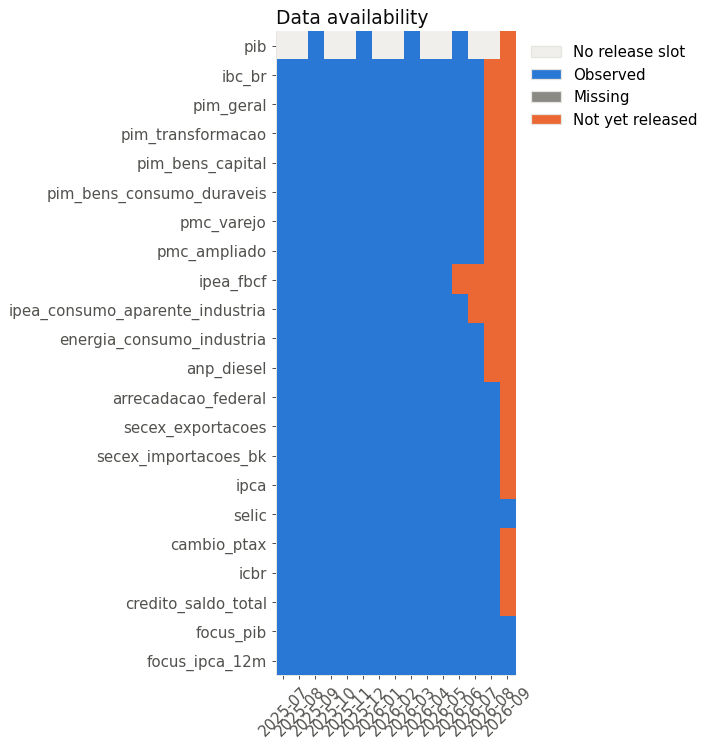

In [3]:
panel = nb.prepare_panel(levels, dataset.transform)
fig = nb.visualization.plot_data_availability(panel, n_periods=15, backend="matplotlib")
show(fig, "09_ragged_edge")

## 3. Estimation

Blocks from the dataset metadata (global + real, nominal, financial, soft), robust
Student-t idiosyncratic errors (innovation I3: large surprises are down-weighted
instead of distorting the factors) and up to 300 EM iterations.

In [4]:
model = nb.MixedFreqDFM(
    n_factors=1, factor_lags=1, blocks="data", idiosyncratic="student_t", max_iter=300
)
res = model.fit(panel, target="pib", horizon=2)  # up to next quarter
print(res.summary(n_periods=6))

                        Nowcast Results: MixedFreqDFM
Target:                 pib (quarterly)
Sample:                 2003-02 .. 2026-09
Series:                 22
Factors:                5
Log-likelihood:         -6975.1129
Iterations:             19
Converged:              True
------------------------------------------------------------------------------
Model parameters
  n_factors             1
  factor_lags           1
  blocks                data
  idiosyncratic         student_t
  max_iter              300
  tol                   0.0001
  init                  pca
  obs_noise_var         0.0001
  filter_method         auto
  df                    -
  outliers              none
  outlier_threshold     4.0000
  exclude_periods       -
  covid                 none
  covid_window          ('2020-03', '2021-12')
  long_run_mean         constant
  long_run_series       -
  long_run_variance     -
------------------------------------------------------------------------------
Factor dy

## 4. The nowcast and its density

In [5]:
current = pd.Period(today, "Q")
last_release = res.observed.dropna().index[-1]
dist = res.distribution(n_boot=0)  # Gaussian predictive density (filtering uncertainty)
band = dist.interval(0.9)
rows = []
for q in pd.period_range(last_release + 1, current + 1, freq="Q"):
    kind = "backcast" if q < current else "nowcast" if q == current else "forecast"
    low, high = band.loc[q]
    rows.append(
        {
            "quarter": str(q),
            "type": kind,
            "QoQ": pct(res.get_nowcast(q)),
            "90% low": pct(low),
            "90% high": pct(high),
        }
    )
display(pd.DataFrame(rows).set_index("quarter"))

,type,QoQ,90% low,90% high
quarter,,,,
2026Q3,backcast,-0.07%,-1.45%,1.31%
2026Q4,nowcast,0.58%,-1.23%,2.40%
2027Q1,forecast,0.63%,-1.19%,2.45%


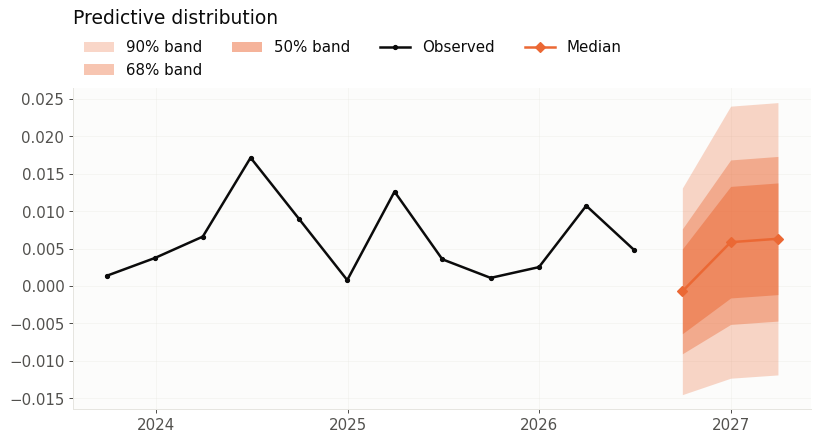

In [6]:
fig = res.plot("fan", backend="matplotlib")
show(fig, "09_fan")

## 5. What changed since last month?

The previous month's information set is rebuilt from the release calendar (pseudo
real time) and the revision of the estimate of the first quarter without a GDP
release is decomposed into news by category.

,step
old nowcast,-1.6074e-03
news: hard,-3.8172e-04
news: soft,8.3772e-05
news: financial,-6.7571e-05
new nowcast,-1.9729e-03


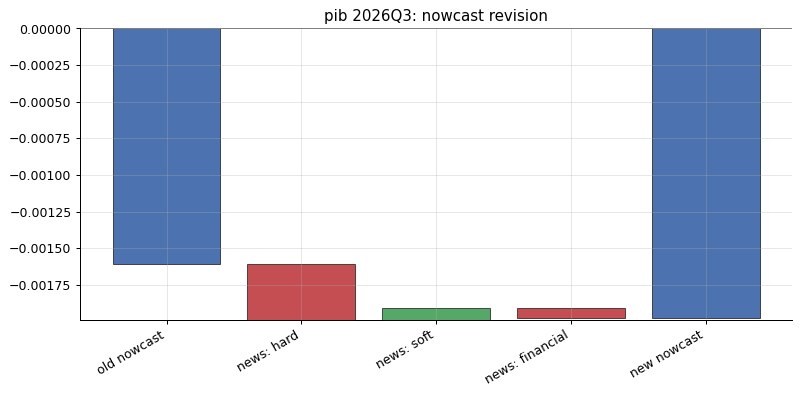

Since 2026-09-01, the estimate of 2026Q3 moved from -0.16% to **-0.20%**; the largest single surprise was `arrecadacao_federal`.

In [7]:
calendar = nb.load_brazil_calendar()
month_ago = today - pd.Timedelta(days=30)
old = nb.pseudo_real_time(panel, calendar=calendar, vintage=month_ago)
focus = last_release + 1  # first quarter without a GDP release
news = res.news(old, panel, target_period=focus)
display(news.waterfall("category").rename("step").to_frame())
fig = news.plot("waterfall", by="category")
show(fig, "09_news")
md(
    f"Since {month_ago.date()}, the estimate of {focus} moved from "
    f"{pct(news.old_nowcast)} to **{pct(news.new_nowcast)}**; the largest single "
    f"surprise was `{news.top_releases(1)['series'].iloc[0]}`."
)

**Note.** With Student-t errors the news decomposition is computed on the Gaussian
version of the estimated model (unit observation weights; a documented limitation of
the robust EM), so its "new nowcast" differs slightly from the robust estimate in the
table above. The decomposition still adds up exactly within that linear model.

## 6. The report

`NowcastReport` assembles a self-contained HTML page (Plotly charts inline): headline
nowcast, path, news, data flow and DFM diagnostics.

In [8]:
report = nb.NowcastReport(
    res,
    title=f"Brazilian GDP nowcast — {today.date()}",
    news=news,
    quantiles=dist,
    diagnostics=True,
    author="nowcastbox example 09",
    notes="Offline run with the shipped data." if not LIVE else "Live data (BCB, IBGE, IPEA).",
)
OUTPUTS_DIR.mkdir(exist_ok=True)
html_path = OUTPUTS_DIR / "09_live_nowcast_report.html"
report.to_html(html_path)
md(f"Report written to `{html_path.relative_to(OUTPUTS_DIR.parent)}`.")

Report written to `outputs/09_live_nowcast_report.html`.

## Running it for real

```bash
export NOWCASTBOX_EXAMPLES_NETWORK=1
jupyter lab examples/notebooks/09_brazil_live_nowcast.ipynb
```

Downloads are cached on disk for a day (`nb.data_sources.default_cache_dir()`), so
re-running is cheap. For a scheduled job, the same chain is expressed declaratively in
a YAML file and run with `nowcastbox run` (notebook 11).

### References

* Bańbura, M. & Modugno, M. (2014). *Journal of Applied Econometrics*, 29(1), 133–160.
* Antolin-Diaz, J., Drechsel, T. & Petrella, I. (2017). Tracking the slowdown in
  long-run GDP growth. *REStat*, 99(2), 343–356 (Student-t robustness).
* Banco Central do Brasil — SGS; IBGE — SIDRA; IPEA — IPEADATA (data sources).